In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns
plt.rcParams['figure.figsize']=(10,10)

In [2]:
data=pd.read_csv(r"D:\jupyter\Stroke Prediction (1)\Stroke Prediction\healthcare-dataset-stroke-data.csv")

In [3]:
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# Exploratory data analysis

In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

# Fill BMI missing values

In [6]:
data['bmi'].value_counts()

bmi
28.7    41
28.4    38
26.7    37
27.6    37
26.1    37
        ..
48.7     1
49.2     1
51.0     1
49.4     1
14.9     1
Name: count, Length: 418, dtype: int64

In [7]:
data['bmi'].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [8]:
data['bmi'].fillna(data['bmi'].mean(),inplace=True)

C:\Users\divya\AppData\Local\Temp\ipykernel_3716\620513141.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bmi'].fillna(data['bmi'].mean(),inplace=True)


In [9]:
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [10]:
data.drop('id',axis=1,inplace=True)

In [11]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


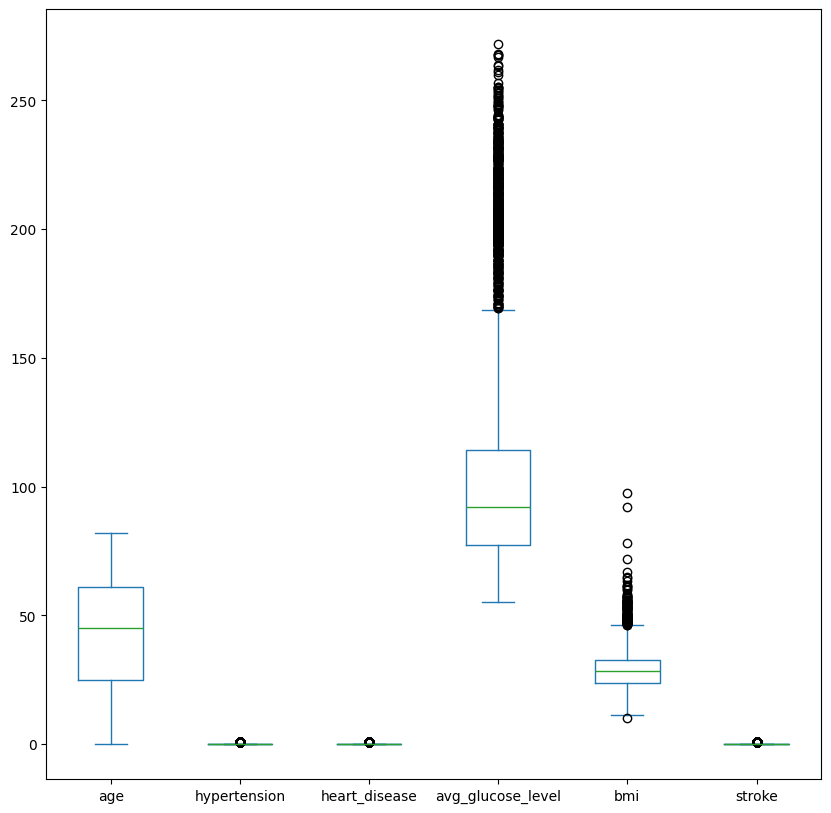

In [12]:
data.plot(kind='box')
plt.show()

In [13]:
data = np.random.normal(0, 1, 100)
data[98:] = [10, 15]  # Add outliers

# Create DataFrame
df = pd.DataFrame({'bmi': data})  # Replace 'salary' with the actual column name

# Check the column names and first few rows
print(df.columns)
print(df.head())

# Calculate IQR for outlier detection
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_cleaned = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]

# Display the cleaned data
print(df_cleaned)

Index(['bmi'], dtype='object')
        bmi
0  0.502228
1  1.478196
2  0.712710
3  0.809655
4 -0.313628
         bmi
0   0.502228
1   1.478196
2   0.712710
3   0.809655
4  -0.313628
..       ...
93 -1.894572
94  0.464173
95  1.076941
96  0.288066
97 -0.621996

[98 rows x 1 columns]


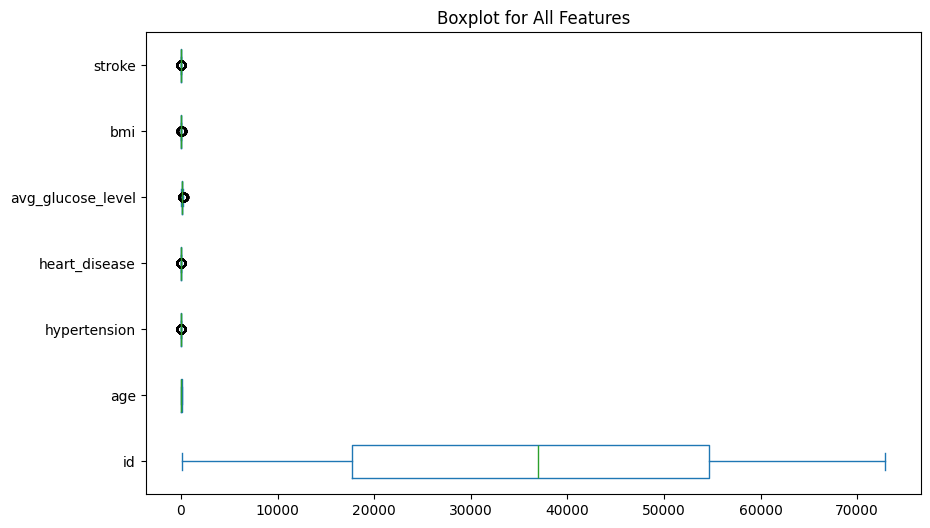

In [14]:
df = pd.read_csv(r"D:\jupyter\Stroke Prediction (1)\Stroke Prediction\healthcare-dataset-stroke-data.csv")  # Or use pd.read_excel() if it's an Excel file



# Plot the boxplot for all features in the dataset
df.plot(kind='box', vert=False, figsize=(10, 6))
plt.title('Boxplot for All Features')
plt.show()

In [15]:
# here we can see the outliers of the various features 
# avg_glucose_levelha so many outler values

In [16]:
data['avg_glucose_level'].describe()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
# 75% data is 114. We can keep this data because people can have higher
# values of bmi or glucose because that may be the reason of the stroke

In [ ]:
data

In [ ]:
data.info()

In [ ]:
#Label Encoding
#as there are objects in the dataset . Machine will not understand the string values of
# work_type,marriage ,smoking values . we need to convert them into values so that machine will be
#able to understand the values

In [ ]:
data['work_type'].unique()

In [ ]:
# we can give values to these like 0,1,2,3 etc

# We are encoding the data here i.e giving values to the objects 

In [ ]:
from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()


In [ ]:
gender=enc.fit_transform(data['gender'])

In [ ]:
smoking_status=enc.fit_transform(data['smoking_status'])

In [ ]:
work_type=enc.fit_transform(data['work_type'])
Residence_type=enc.fit_transform(data['Residence_type'])
ever_married=enc.fit_transform(data['ever_married'])

In [ ]:
ever_married

# Replacing the old values of features with the encoded values 

In [ ]:
data['work_type']=work_type

In [ ]:
data['ever_married']=ever_married
data['Residence_type']=Residence_type
data['smoking_status']=smoking_status
data['gender']=gender

In [ ]:
data

In [ ]:
data.info()

# Partitioning

In [ ]:
#Splitting the data for train and test

In [ ]:
# X----- features(train_X,test_X) (80,20)
# Y-----target(labels of X) train_Y,test_Y

In [ ]:
X=data.drop('stroke',axis=1)

In [ ]:
X

In [ ]:
Y=data['stroke']

In [ ]:
Y

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test , y_train, Y_test=train_test_split(X,Y,test_size=0.2,random_state=101)

In [ ]:
X_train

In [ ]:
y_train

In [ ]:
X_test

In [ ]:
Y_test

# Normalisation

In [ ]:
data.describe()

In [ ]:
#data is not in a particular range . we need to bring it in a particular level 
#mean will be 0 . std deviation will be 1
#onr need to transfrom x 

In [ ]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()

In [ ]:
X_train_std=std.fit_transform(X_train)

X_test_std=std.transform(X_test)


In [ ]:
X_test_std

In [ ]:
X_train_std

# Training

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

In [ ]:
dt.fit(X_train_std,y_train)

In [ ]:
dt.feature_importances_

In [ ]:
X_train.columns

In [ ]:
# here we can see age,avg_glucose and bmi are most imp factors

In [ ]:
Y_pred=dt.predict(X_test_std)

In [ ]:
Y_test

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
ac_dt=accuracy_score(Y_test,Y_pred)

In [ ]:
ac_dt

In [ ]:
# As we can see that accuracy tp DT algo is around 90%

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [ ]:
lr.fit(X_train_std,y_train)

In [ ]:
Y_pred=lr.predict(X_test_std)

In [ ]:
ac_lr=accuracy_score(Y_test,Y_pred)

In [ ]:
ac_lr

In [ ]:
# Accuracy of LR algo is around 94.7%

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [ ]:
knn.fit(X_train_std,y_train)

In [ ]:
Y_pred=knn.predict(X_test_std)

In [ ]:
ac_knn=accuracy_score(Y_test,Y_pred)

In [ ]:
ac_knn

In [ ]:
#Accuracy of KNN algo is around 94.5%

# Random Forest algo

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()

In [ ]:
rf.fit(X_train,y_train)

In [ ]:
Y_pred=rf.predict(X_test)

In [ ]:
ac_rf=accuracy_score(Y_test,Y_pred)

In [ ]:
ac_rf

In [ ]:
#Accuracy score is 94.61%

# SVM



In [ ]:
from sklearn.svm import SVC

In [ ]:
sv=SVC()

In [ ]:
sv.fit(X_train_std,y_train)

In [ ]:
Y_pred=sv.predict(X_test_std)

In [ ]:
ac_sv=accuracy_score(Y_test,Y_pred)

In [ ]:
ac_sv

In [ ]:
# Accuracy score of SVM is 94.71%



In [ ]:
plt.bar(['Decision Tree', 'Logistic ','KNN', 'Random Forest','SVM'], [ac_dt,ac_lr,ac_knn,ac_rf,ac_sv])
plt.xlabel(" ML Algorithms")
plt.ylabel("Accuracy Score")
plt.show()

In [ ]:
from xgboost import XGBClassifier
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=50, max_depth=5, min_samples_leaf=10, min_samples_split=20, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=50, max_depth=5, learning_rate=0.05, reg_alpha=1, reg_lambda=1, random_state=42, eval_metric='logloss')
}

# Dictionary to store accuracies
training_accuracies = []
test_accuracies = []

# Train each model and calculate accuracies
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Training accuracy
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    training_accuracies.append(train_acc)
    
    # Test accuracy
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(Y_test, test_pred)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
x = range(len(models))

# Bar chart for training and test accuracy
plt.bar(x, training_accuracies, width=0.4, label='Training Accuracy', color='skyblue', align='center')
plt.bar(x, test_accuracies, width=0.4, label='Test Accuracy', color='lightgreen', align='edge')

# Add labels and titles
plt.xticks(x, models.keys(), rotation=15)
plt.ylim(0, 1)  # Accuracy is between 0 and 1
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy for Different Models')
plt.legend()

# Annotate bars with accuracy values
for i in range(len(models)):
    plt.text(i - 0.2, training_accuracies[i] + 0.02, f"{training_accuracies[i]:.2f}", ha='center', fontsize=9)
    plt.text(i + 0.2, test_accuracies[i] + 0.02, f"{test_accuracies[i]:.2f}", ha='center', fontsize=9)

# Show the plot
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()